In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 /(N-1) * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon


def run_dynamics_lmg(args):
    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]
    en, sts = Sx.eigenstates() 
    rho = sts[0]
    psi_ph = basis(n_ph,0)
    rho0 = tensor(rho, psi_ph)
    results = mesolve(H_td, rho0, tlist, [], [n_photon], args = args, options=args['opts'])
    op_n_photon = results.expect[0]

    return op_n_photon

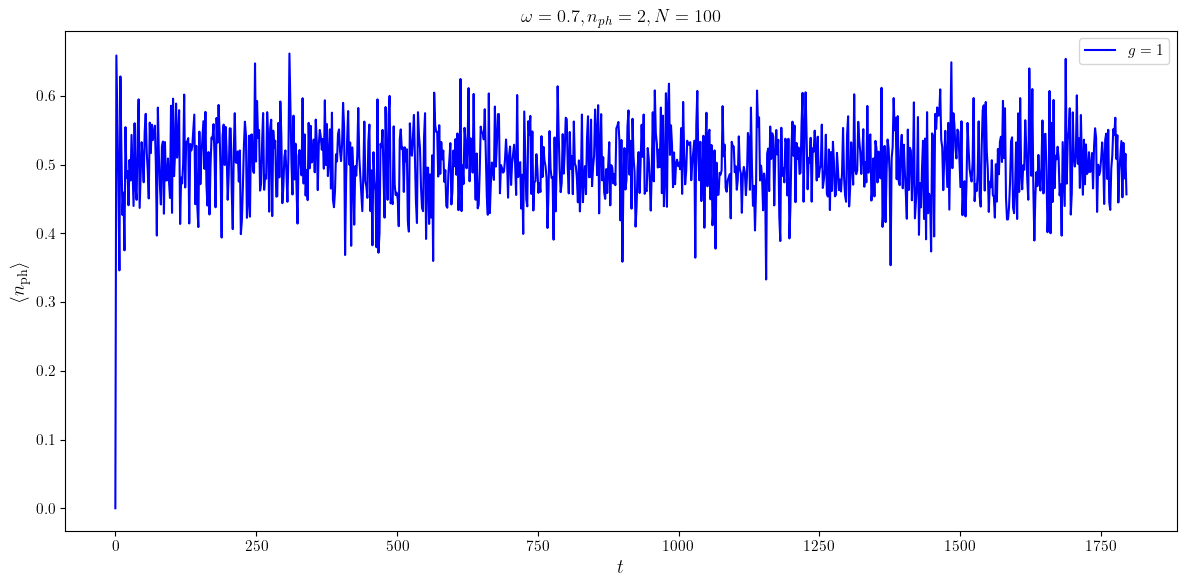

In [3]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

plt.rcParams.update({"figure.figsize": (12,6), "font.size": 11, "text.usetex": True})
# parameters
N = 100
omega = 0.7
hbar = 1.0
h0 = 0
n_ph = 100
omega0 = 1.0
Jvalue = 1.0

gvals = [0.1, 1]
#Nvals = [10, 30, 50, 100, 150, 200, 300, 400]
#Nvals = [4, 5, 6]
opts = Options(nsteps =1e6, atol=1e-10, rtol=1e-8)

T = 2 * np.pi/omega
tlist = np.linspace(0,200*T, 1000)
h = jn_zeros(0,5)[1]* omega / 4.0

colors = ['blue', 'green']
styles = ['-', '--']
for g, c, s in zip(gvals, colors, styles):
    
    args_list = {'tlist': tlist, 'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega, 'opts': opts}            
    op_n_photon = run_dynamics_lmg(args_list)    
    np.savez(f'New_Average_photon_number_N_{N}_n_ph_{n_ph}_g_{g}.npz', op_n_photon=op_n_photon, tlist=tlist)
    plt.plot(tlist, op_n_photon, label=rf'$g={g}$', color=c, linestyle=s)

plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$\langle n_{\mathrm{ph}}\rangle$', fontsize=14)
plt.title(rf'$\omega={omega}, n_{{ph}}={n_ph}, N={N}$')
plt.tight_layout()
plt.legend()
plt.savefig(f'plots/New_Average_photon_number_n_ph_{n_ph}_N_{N}_omega_{omega}_g_{g}.png', dpi=300, bbox_inches='tight')
plt.show()